# Protein fitness landscape analysis

In this tutorial, we’ll use GraphFLA to explore how combinations of mutations shape a protein’s fitness. To see how this works, we’ll build and analyse a landscape from a deep mutational scan of the GB1 protein domain, then measure its ruggedness, epistasis and navigability.


## 1. Setting up

On Google Colab, the cell below installs GraphFLA. In any environment, it also downloads the dataset into a `data/` folder next to the notebook if the files are not already there.

We then import GraphFLA for landscape construction and analysis, pandas for working with the data, and NumPy and Matplotlib for plotting interactions.

In [1]:
import sys
from pathlib import Path
from urllib.request import urlretrieve

if "google.colab" in sys.modules:
    %pip install -q graphfla==0.4.0

DATA_URL = "https://raw.githubusercontent.com/COLA-Laboratory/GraphFLA/v0.4.0/tutorials/datasets/data/"
Path("data").mkdir(exist_ok=True)
for name in ["gb1.csv"]:
    if not Path("data", name).exists():
        urlretrieve(DATA_URL + name, Path("data", name))

In [2]:
from graphfla import analysis
from graphfla.landscape import ProteinLandscape
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 2. Loading the dataset

Protein G is a bacterial surface protein that binds antibodies, and its B1 domain (GB1) is a long-standing model for studying protein evolution. [Wu et al. (2016)](https://doi.org/10.7554/eLife.16965) mutated four positions of GB1, **V39, D40, G41 and V54**, to all 20 amino acids, giving **20⁴ = 160,000 variants**. They measured fitness for **149,361 variants (93.4%)** in a selection for binding to an antibody fragment (IgG-Fc), which reflects both folding and binding.

We’ll maximise this fitness. Each value is relative to the wild type, `VDGV`, whose fitness is 1.

| Column | Meaning |
|---|---|
| `sequences` | Amino acids at positions 39, 40, 41 and 54, in that order. |
| `residue_39` … `residue_54` | Amino acid at each mutated position. |
| `fitness` | Fitness relative to the wild type. |

Let’s load the measured variants. The authors also imputed fitness for the 10,639 unmeasured variants; we leave those out so that every value comes from an experiment.


In [3]:
df = pd.read_csv("data/gb1.csv")
df.head()


,sequences,residue_39,residue_40,residue_41,residue_54,fitness
0,VDGV,V,D,G,V,1.000000
1,ADGV,A,D,G,V,0.061910
2,CDGV,C,D,G,V,0.242237
3,DDGV,D,D,G,V,0.006472
4,EDGV,E,D,G,V,0.032719


## 3. Preparing the inputs

To construct a landscape, GraphFLA needs two aligned inputs:

- `X`: one row per configuration and one column per variable.
- `f`: one measured or calculated outcome for each row of `X`.

The four residue columns form `X`, and fitness forms `f`. Each row is one protein variant; the other 52 residues of the domain are fixed, so they are not variables in this landscape.

In [4]:
X = df[["residue_39", "residue_40", "residue_41", "residue_54"]]
f = df["fitness"]
X.head()


,residue_39,residue_40,residue_41,residue_54
0,V,D,G,V
1,A,D,G,V
2,C,D,G,V
3,D,D,G,V
4,E,D,G,V


## 4. Constructing the landscape

We can use `ProteinLandscape`, which treats each position as one of the 20 amino acids. Neighbouring variants differ by a single substitution at one position, and improving edges point from lower to higher fitness. We set `maximize=True` because higher fitness is better.

About 29,000 variants have a fitness of exactly zero. Neighbours with equal fitness are stored as neutral pairs rather than improving moves, and connected neutral variants form a *plateau*.


In [5]:
landscape = ProteinLandscape(maximize=True)
landscape.build_from_data(X, f, verbose=False)


ProteinLandscape(maximize=True)

## 5. Inspecting the landscape

Let’s first look at what we’ve built. Printing the landscape shows its variables, configurations, improving edges and local optima:


In [6]:
print(landscape)


ProteinLandscape(kind='protein'): 4 variables, 149361 configurations, 5074326 edges, 184 local optima


For a closer look at individual variants, we can call `get_data()`. The outcome appears as `fitness`; `out_degree` counts directly improving moves, and `is_lo` indicates local-optimum membership.


In [7]:
landscape.get_data().head()


,residue_39,residue_40,residue_41,residue_54,fitness,plateau_id,plateau_size,in_degree,out_degree,is_lo
0,V,D,G,V,1.000000,-1,1,56,20,False
1,A,D,G,V,0.061910,-1,1,30,30,False
2,C,D,G,V,0.242237,-1,1,50,25,False
3,D,D,G,V,0.006472,-1,1,26,48,False
4,E,D,G,V,0.032719,-1,1,40,35,False


We can also summarise the fitness values with pandas:


In [8]:
landscape.get_data()["fitness"].describe()


count    149361.000000
mean          0.080510
std           0.395391
min           0.000000
25%           0.001370
50%           0.003384
75%           0.008986
max           8.761966
Name: fitness, dtype: float64

Most variants bind far worse than the wild type: the median fitness is below 0.01. To inspect the fittest variant, we can use the global-optimum node index:


In [9]:
landscape[landscape.go_index]


{'residue_39': 'F',
 'residue_40': 'W',
 'residue_41': 'A',
 'residue_54': 'A',
 'fitness': np.float64(8.761965656),
 'plateau_id': -1,
 'plateau_size': 1,
 'in_degree': 75,
 'out_degree': 0,
 'is_lo': True}

## 6. Analysing the landscape

Next, we’ll follow three questions in turn: how rugged the landscape is (6.1–6.2), which kinds of epistasis make it so (6.3–6.6), and whether evolution can still reach the best variant (6.7–6.8).


### 6.1 Number of local optima

We can start with `landscape.n_lo`. A local optimum, or fitness peak, is a variant without a fitter single-mutant neighbour; each connected neutral plateau of peaks counts once. Many peaks mean that adaptive walks, which accept only fitness-increasing mutations, can end at different variants.


In [10]:
print(f"Number of local optima: {landscape.n_lo}")


Number of local optima: 184


Many of these peaks have very low fitness. We can count the peak variants that are fitter than the wild type:


In [11]:
peaks = landscape.get_data(lo_only=True)
print(f"Peaks fitter than the wild type: {(peaks['fitness'] > 1).sum()}")


Peaks fitter than the wild type: 15


Wu et al. reported 30 peaks in their imputed landscape of all 160,000 variants, 15 of them fitter than the wild type. The measured variants give the same number of peaks above the wild type. Almost all of the remaining peaks have fitness below 0.1 and lack at least one measured neighbour; an unmeasured fitter neighbour cannot be counted, so a missing variant can leave a peak in the data.


### 6.2 Roughness-to-slope ratio

The peak count shows that the landscape is rugged, but not how far it departs from the simplest case. If every mutation had the same effect in every background, fitness would be additive and the landscape would have a single peak. The roughness-to-slope ratio, introduced by [Aita et al. (2000)](https://doi.org/10.1002/(SICI)1097-0282(200007)54:1%3C64::AID-BIP70%3E3.0.CO;2-R), measures this departure: it fits an additive model and compares the scatter left unexplained with the average size of the mutation effects. Values near zero indicate a nearly additive landscape; larger values indicate a more rugged one.

`r_s_ratio()` encodes each position relative to a reference amino acid, so we compare values only when they are calculated in the same way.


In [12]:
roughness_to_slope = analysis.r_s_ratio(landscape)
print(f"Roughness-to-slope ratio: {roughness_to_slope:.4f}")


Roughness-to-slope ratio: 2.4772


### 6.3 Gamma star

Not every departure from additivity creates peaks. A mutation that is beneficial in every background still leads uphill; multiple peaks can arise only when mutation effects reverse direction between backgrounds, known as sign epistasis. [Ferretti et al. (2016)](https://doi.org/10.1016/j.jtbi.2016.01.037) proposed measuring epistasis by how well a mutation’s effect carries over when a second mutation is added to the background. `gamma_star()` applies this idea to the direction of effects only; we run it in a single process (`n_jobs=1`), which is fast enough here.

A value of 1 means mutations never switch between beneficial and deleterious; values near zero indicate frequent switches, and negative values indicate that pairs of mutations often reverse each other’s direction (reciprocal sign epistasis).


In [13]:
sign_correlation = analysis.gamma_star(landscape, n_jobs=1)
print(f"Gamma star: {sign_correlation:.4f}")


Gamma star: 0.2550


### 6.4 Idiosyncratic epistasis

Gamma star records only whether effects change direction. Even when the direction holds, the size of an effect can change from one background to another. [Lyons et al. (2020)](https://doi.org/10.1038/s41559-020-01286-y) introduced the idiosyncratic index to measure this variation: it compares the spread of a mutation’s effects across backgrounds with the fitness differences between randomly paired variants. A value of zero means each mutation has the same effect everywhere; a value near one means its effect varies about as much as the difference between two random variants.

`global_idiosyncratic_index()` averages this index over all mutations. Random pairs are drawn with a fixed seed.


In [14]:
idiosyncrasy = analysis.global_idiosyncratic_index(landscape, seed=42, n_jobs=1)
print(f"Global idiosyncratic index: {idiosyncrasy:.4f}")


Global idiosyncratic index: 0.6098


### 6.5 Walsh–Hadamard decomposition

Gamma star and the idiosyncratic index summarise epistasis across the whole landscape, but they do not show which positions are responsible. `walsh_hadamard()` helps locate it by describing fitness as a sum of single-mutation effects and interactions between pairs of positions, using the multistate extension of [Faure et al. (2024)](https://doi.org/10.1371/journal.pcbi.1012132). We stop at pairs, leaving interactions among three or four positions unresolved.

A pairwise fit has 2,243 coefficients. Three amino-acid combinations at positions 39 and 54 were never measured, so ordinary least squares cannot identify every coefficient. We therefore use Lasso regularisation with a cross-validated penalty. To keep memory use and run time manageable, we fit a random sample of 20,000 measured variants with a fixed seed. Its design matrix still has about 45 million entries, so we raise the default `max_cells` safeguard of 10 million.

Compare the first- and second-order training `r2`; `delta_r2` shows the extra variation explained by pairwise terms. `model_variance_fraction` splits the variance of the fitted model between additive and pairwise terms.


In [15]:
sample = df.sample(20_000, random_state=42)
wh_landscape = ProteinLandscape(maximize=True).build_from_data(
    sample[X.columns], sample["fitness"], verbose=False,
)
wh = analysis.walsh_hadamard(
    wh_landscape, max_order=2, max_cells=5e7, method="lasso", alpha="cv",
    cv=5, random_state=42, n_jobs=1,
)
wh["order_summary"][[
    "order", "r2", "delta_r2", "rmse", "alpha", "model_variance_fraction",
]]


,order,r2,delta_r2,rmse,alpha,model_variance_fraction
0,0,0.000000,0.000000,0.377487,NaN,0.000000
1,1,0.194727,0.194727,0.338745,0.000015,0.312703
2,2,0.638796,0.444069,0.226870,0.000015,0.687297


Which positions carry this variation? The helper functions below split the fitted model’s variance, taken over all possible combinations of amino acids, into a share for each position (diagonal) and for each pair of positions (off-diagonal). The diagonal holds the additive part and the off-diagonal cells the pairwise part; each pair appears twice, and the diagonal plus one triangle add up to 100%. Unlike individual coefficients, these shares do not depend on the reference amino acid.

As a check, the pairwise shares add up to the order-2 `model_variance_fraction` in the table above.


In [16]:
def term_variance(block):
    """Variance of one fitted term over all allele combinations."""
    alleles = [
        part.str.extract(r"^(?P<ref>\w)_\d+_(?P<alt>\w)$")
        for _, part in block["term"].str.split("-", expand=True).items()
    ]
    states = [sorted({a["ref"].iloc[0], *a["alt"]}) for a in alleles]
    # Reference alleles keep a zero coefficient.
    effects = np.zeros([len(s) for s in states])
    for k, coefficient in enumerate(block["coefficient"]):
        cell = tuple(s.index(a["alt"].iloc[k]) for s, a in zip(states, alleles))
        effects[cell] = coefficient
    for axis in range(effects.ndim):
        effects = effects - effects.mean(axis=axis, keepdims=True)
    return np.mean(effects**2)


def variance_shares(coefficients, n_positions):
    """Share of fitted variance from each position (diagonal) and pair."""
    shares = np.zeros((n_positions, n_positions))
    for positions, block in coefficients.query("order > 0").groupby("positions"):
        i, j = positions[0] - 1, positions[-1] - 1
        shares[i, j] = shares[j, i] = term_variance(block)
    return shares / (np.trace(shares) + np.triu(shares, 1).sum())


def plot_shares(shares, labels):
    n = len(labels)
    size = min(0.55 * n, 6.0)
    percent = 100 * shares
    fig, ax = plt.subplots(figsize=(size + 2.4, size + 1.6))
    image = ax.imshow(percent, cmap="viridis")
    ax.set_xticks(range(n), labels, rotation=90 if n > 6 else 0)
    ax.set_yticks(range(n), labels)
    if n <= 9:
        midpoint = percent.max() / 2
        for (i, j), value in np.ndenumerate(percent):
            color = "black" if value > midpoint else "white"
            ax.text(j, i, f"{value:.1f}", ha="center", va="center",
                    fontsize=8, color=color)
    fig.colorbar(image, ax=ax, label="Share of fitted variance (%)")
    fig.tight_layout()
    plt.show()


Pairwise share of fitted variance: 0.687


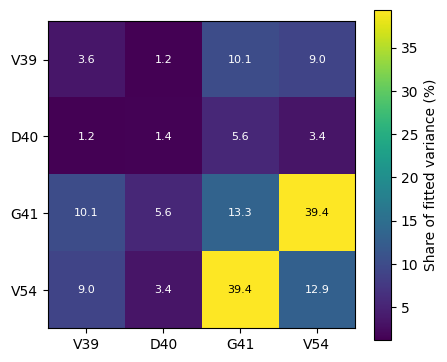

In [17]:
shares = variance_shares(wh["coefficients"], n_positions=4)
print(f"Pairwise share of fitted variance: {np.triu(shares, 1).sum():.3f}")
plot_shares(shares, labels=["V39", "D40", "G41", "V54"])


### 6.6 Diminishing returns and increasing costs

Interactions between particular positions are one source of background dependence. Another is a general trend with how fit the background already is, known as global epistasis. Beneficial mutations can help less in fitter backgrounds, known as diminishing returns ([Chou et al., 2011](https://doi.org/10.1126/science.1203799)), while deleterious mutations can cost more, known as increasing costs ([Johnson et al., 2019](https://doi.org/10.1126/science.aay4199)).

`diminishing_returns_index()` correlates background fitness with the gain of each beneficial mutation; a negative value indicates diminishing returns. `increasing_costs_index()` correlates background fitness with the loss of each deleterious mutation; a positive value indicates increasing costs. Both pool all mutations together and depend on the fitness scale.


In [18]:
returns = analysis.diminishing_returns_index(landscape)
costs = analysis.increasing_costs_index(landscape)
print(f"Diminishing returns index: {returns:.4f}")
print(f"Increasing costs index: {costs:.4f}")


Diminishing returns index: 0.2768
Increasing costs index: 0.9229


### 6.7 Global optimum accessibility

Ruggedness and epistasis matter for evolution because peaks can trap adaptive walks. `global_optima_accessibility()` asks whether the fittest variant can still be reached: it returns the fraction of variants from which some path of fitness-increasing single mutations leads to the global optimum. A value of 1 means every variant has such a path; a small value means most adaptive walks must end at other peaks.


In [19]:
accessibility = analysis.global_optima_accessibility(landscape)
print(f"Global optimum accessibility: {accessibility:.4f}")


Global optimum accessibility: 0.9976


### 6.8 Fitness-distance correlation

Accessibility tells us whether an uphill path to the global optimum exists, not whether fitness points towards it. [Jones and Forrest (1995)](https://fluidinfo.com/research/fdc-abs.html) introduced fitness-distance correlation for this question. `fdc()` correlates each variant’s fitness with its number of mutations from the global optimum. A negative value means fitter variants tend to lie closer to the best variant; a value near zero means distance tells us little about fitness.


In [20]:
fitness_distance_r = analysis.fdc(landscape, method="spearman")
print(f"Fitness-distance correlation: {fitness_distance_r:.4f}")


Fitness-distance correlation: -0.1231


In summary, the GB1 landscape is rugged, with 184 peaks and an r/s ratio of 2.48. Much of this ruggedness comes from epistasis: mutation effects often change direction (γ* = 0.255) and vary widely between backgrounds (idiosyncratic index 0.610), and pairwise terms account for 69% of the fitted variance, with the G41–V54 pair alone contributing 39%. On this relative fitness scale, both gains and losses tend to be larger in fitter backgrounds (0.277 and 0.923), so these data show no overall diminishing returns. Despite the ruggedness, 99.8% of variants have a fitness-increasing path to the global optimum, even though distance to it is a weak guide to fitness (FDC −0.123).


## 7. Running several analyses together

We can collect the single-value metrics above with `analysis.profile()`, using the same seed for the idiosyncratic index. `landscape.n_lo` supplies the peak count directly; the W–H result keeps its separate coefficient and order-summary tables.


In [21]:
analysis.profile(
    landscape,
    metrics=[
        "r_s_ratio", "gamma_star", "global_idiosyncratic_index",
        "diminishing_returns_index", "increasing_costs_index",
        "global_optima_accessibility", "fdc",
    ],
    seed=42, n_jobs=1, progress=False,
)


r_s_ratio                      2.477187
gamma_star                     0.254968
global_idiosyncratic_index     0.609828
diminishing_returns_index      0.276792
increasing_costs_index         0.922856
global_optima_accessibility    0.997563
fdc                           -0.123074
dtype: float64

## 8. Analysis reference

For further exploration, `analysis.list_metrics()` lists the metrics available to `profile()`. The worked W–H result also exposes `fit_info`; its order summary separates cumulative training fit from the fitted model’s variance spectrum.

### Data sources

Wu N. C. et al. (2016). [Adaptation in protein fitness landscapes is facilitated by indirect paths](https://doi.org/10.7554/eLife.16965). We use the measured fitness values from Supplementary file 1, without the imputed variants in Supplementary file 2.